#### 1 -Libraries import

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#### 2. Dataset load

In [3]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### 3 Basic Preprocessing
- TotalCharges clean karo

- Model ke liye TotalCharges numeric hona chahiye:

- 3.1 Convert TotalCharges to numeric

In [ ]:
df['TotalCharges'].isnull().sum()

In [5]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [6]:
df['TotalCharges'].isnull().sum()

np.int64(11)

- 3.2 fill Missing totalCharges

In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

3.3 customerID remove
- customerID unique identifier hai. Model ke liye useful predictive feature nahi hai.

In [8]:
df = df.drop('customerID', axis=1)

3.4 Convert target to 0/1

In [11]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [9]:
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [10]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

#### 4. separat input and output

In [12]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [13]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


#### 5 Train/Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### 6. identify numerical and categorical column

In [15]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object', 'str']).columns

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

Categorical Features:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


#### 7. Prerpocessing pipeline

In [16]:
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

In [17]:
categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

#### 8. Train model

- 8.1 Logistic Regression Pipeline

In [19]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [20]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

- 8.2 — Random Forest Model

In [21]:
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [22]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [23]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
1,Random Forest,0.783534,0.618557,0.481283,0.541353,0.820602


Logistic Regression ke metrics Random Forest se higher hain.

Confusion Matrix

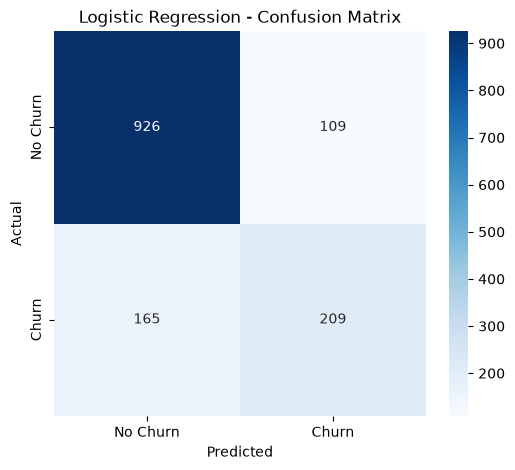

In [24]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

4 values ka meaning
- TN = 926 → Actual customer churn nahi hua, model ne bhi No Churn bola. ✅
- FP = 109 → Actual churn nahi hua, model ne galti se Churn bola. ❌
- FN = 165 → Actual churn hua, lekin model ne No Churn bola. ❌
- TP = 209 → Actual churn hua, model ne correctly Churn bola. ✅

- Sabse important yahan FN = 165 hai.

- Matlab 165 customers actually churn hue, lekin model unhe identify nahi kar paya.

https://chatgpt.com/s/w_6ab8f1f955248191aaa25ad9f6c510e4

Ab hum Random Forest ki confusion matrix nahi, balki directly Logistic Regression ko tune karenge.

#### Optuna Optimization

In [25]:
import optuna

In [26]:
def objective(trial):

    C = trial.suggest_float(
        'C',
        0.001,
        10.0,
        log=True
    )

    model = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', LogisticRegression(
                C=C,
                max_iter=1000
            ))
        ]
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    return roc_auc_score(y_test, y_prob)

In [27]:
study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=30
)

[I 2026-09-27 16:12:18,530] A new study created in memory with name: no-name-8c9fc4af-6b3a-4374-8b3b-ed036e939155
[I 2026-09-27 16:12:18,700] Trial 0 finished with value: 0.8368415613939911 and parameters: {'C': 0.0031657474912081944}. Best is trial 0 with value: 0.8368415613939911.
[I 2026-09-27 16:12:18,842] Trial 1 finished with value: 0.8418610659019866 and parameters: {'C': 0.20853370344189404}. Best is trial 1 with value: 0.8418610659019866.
[I 2026-09-27 16:12:19,017] Trial 2 finished with value: 0.8420651528068408 and parameters: {'C': 1.653374558134893}. Best is trial 2 with value: 0.8420651528068408.
[I 2026-09-27 16:12:19,186] Trial 3 finished with value: 0.837766410912191 and parameters: {'C': 0.006756606918710024}. Best is trial 2 with value: 0.8420651528068408.
[I 2026-09-27 16:12:19,291] Trial 4 finished with value: 0.8400268671368415 and parameters: {'C': 0.04392855413831547}. Best is trial 2 with value: 0.8420651528068408.
[I 2026-09-27 16:12:19,396] Trial 5 finished w

In [28]:
print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)

Best ROC-AUC: 0.8421659045699967
Best Parameters: {'C': 0.7794718226379}


16 — Best Parameters se Tuned Model

Ab best C use karke final tuned Logistic Regression train karte hain.

In [29]:
best_C = study.best_params['C']

tuned_lr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            C=best_C,
            max_iter=1000
        ))
    ]
)

tuned_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [30]:
y_pred_tuned = tuned_lr.predict(X_test)
y_prob_tuned = tuned_lr.predict_proba(X_test)[:, 1]


In [31]:
tuned_results = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1 Score': f1_score(y_test, y_pred_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_prob_tuned)
}

pd.DataFrame([tuned_results])

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.804826,0.655172,0.558824,0.603175,0.842166


In [32]:
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=['No Churn', 'Churn']
))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [33]:
from sklearn.ensemble import GradientBoostingClassifier

In [34]:
gradient_boosting_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [35]:
y_pred_gb = gradient_boosting_model.predict(X_test)
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

In [36]:
gb_results = {
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'F1 Score': f1_score(y_test, y_pred_gb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_gb)
}

pd.DataFrame([gb_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.802697,0.665517,0.516043,0.581325,0.843275


In [38]:
import xgboost as xgb

print(xgb.__version__)

3.2.0


#### XGBoost

In [39]:
from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric='logloss'
        ))
    ]
)

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [40]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [41]:
xgb_results = {
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1 Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_xgb)
}

pd.DataFrame([xgb_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.807665,0.675768,0.529412,0.593703,0.844515


In [42]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [43]:
hist_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), categorical_features)
    ]
)

In [44]:
hist_gb_model = Pipeline(
    steps=[
        ('preprocessor', hist_preprocessor),
        ('model', HistGradientBoostingClassifier(
            max_iter=100,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

hist_gb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [45]:
y_pred_hist = hist_gb_model.predict(X_test)
y_prob_hist = hist_gb_model.predict_proba(X_test)[:, 1]

In [46]:
hist_results = {
    'Model': 'HistGradientBoosting',
    'Accuracy': accuracy_score(y_test, y_pred_hist),
    'Precision': precision_score(y_test, y_pred_hist),
    'Recall': recall_score(y_test, y_pred_hist),
    'F1 Score': f1_score(y_test, y_pred_hist),
    'ROC-AUC': roc_auc_score(y_test, y_prob_hist)
}

pd.DataFrame([hist_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,HistGradientBoosting,0.790632,0.624606,0.529412,0.573082,0.832806


23 — Cross-Validation import

In [47]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [48]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Step 24 — Logistic Regression ka new Optuna objective

In [50]:
def objective_lr_cv(trial):

    C = trial.suggest_float(
        'C',
        0.001,
        10.0,
        log=True
    )

    model = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', LogisticRegression(
                C=C,
                max_iter=1000
            ))
        ]
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

25 — Optuna run

In [51]:
study_lr = optuna.create_study(
    direction='maximize'
)

study_lr.optimize(
    objective_lr_cv,
    n_trials=30
)

[I 2026-09-27 16:34:45,846] A new study created in memory with name: no-name-1ac90fbc-a822-4cc7-a8a8-9ebbfb4419a9
[I 2026-09-27 16:34:49,232] Trial 0 finished with value: 0.8458814800149208 and parameters: {'C': 0.2598509442414318}. Best is trial 0 with value: 0.8458814800149208.
[I 2026-09-27 16:34:52,155] Trial 1 finished with value: 0.8454870138934435 and parameters: {'C': 0.09916576191218791}. Best is trial 0 with value: 0.8458814800149208.
[I 2026-09-27 16:34:54,485] Trial 2 finished with value: 0.8459946106623806 and parameters: {'C': 0.36859464978438816}. Best is trial 2 with value: 0.8459946106623806.
[I 2026-09-27 16:34:54,642] Trial 3 finished with value: 0.8433128693391378 and parameters: {'C': 0.009137885244831109}. Best is trial 2 with value: 0.8459946106623806.
[I 2026-09-27 16:34:54,813] Trial 4 finished with value: 0.8461125932688255 and parameters: {'C': 0.4790156929635543}. Best is trial 4 with value: 0.8461125932688255.
[I 2026-09-27 16:34:54,968] Trial 5 finished wi

In [52]:
print("Best CV ROC-AUC:", study_lr.best_value)
print("Best Parameters:", study_lr.best_params)

Best CV ROC-AUC: 0.8464157396025606
Best Parameters: {'C': 3.7015496756976765}


26 — Tuned Logistic Regression

In [53]:
best_lr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            C=study_lr.best_params['C'],
            max_iter=1000
        ))
    ]
)

best_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [54]:
y_pred_best_lr = best_lr.predict(X_test)
y_prob_best_lr = best_lr.predict_proba(X_test)[:, 1]

In [55]:
best_lr_results = {
    'Model': 'Logistic Regression - Tuned',
    'Accuracy': accuracy_score(y_test, y_pred_best_lr),
    'Precision': precision_score(y_test, y_pred_best_lr),
    'Recall': recall_score(y_test, y_pred_best_lr),
    'F1 Score': f1_score(y_test, y_pred_best_lr),
    'ROC-AUC': roc_auc_score(y_test, y_prob_best_lr)
}

pd.DataFrame([best_lr_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression - Tuned,0.805536,0.657233,0.558824,0.604046,0.84174


Random Forest tuning

In [56]:
def objective_rf_cv(trial):

    n_estimators = trial.suggest_int(
        'n_estimators', 100, 500, step=50
    )

    max_depth = trial.suggest_int(
        'max_depth', 3, 20
    )

    min_samples_split = trial.suggest_int(
        'min_samples_split', 2, 20
    )

    min_samples_leaf = trial.suggest_int(
        'min_samples_leaf', 1, 10
    )

    model = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42,
                n_jobs=-1
            ))
        ]
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

In [57]:
study_rf = optuna.create_study(direction='maximize')

study_rf.optimize(
    objective_rf_cv,
    n_trials=30
)

print("Best CV ROC-AUC:", study_rf.best_value)
print("Best Parameters:", study_rf.best_params)

[I 2026-09-27 16:38:54,619] A new study created in memory with name: no-name-80d69df7-6221-4416-92a0-90c3e5e75c11
[I 2026-09-27 16:38:55,514] Trial 0 finished with value: 0.8430254364364949 and parameters: {'n_estimators': 200, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.8430254364364949.
[I 2026-09-27 16:38:57,098] Trial 1 finished with value: 0.8399225383331623 and parameters: {'n_estimators': 500, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.8430254364364949.
[I 2026-09-27 16:38:58,722] Trial 2 finished with value: 0.8459333218339854 and parameters: {'n_estimators': 400, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.8459333218339854.
[I 2026-09-27 16:39:00,330] Trial 3 finished with value: 0.8424794928783654 and parameters: {'n_estimators': 400, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 3}. Best is trial 2 with value: 

Best CV ROC-AUC: 0.8483139716041908
Best Parameters: {'n_estimators': 250, 'max_depth': 8, 'min_samples_split': 11, 'min_samples_leaf': 8}


Tuned Random Forest train karo

In [58]:
best_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=study_rf.best_params['n_estimators'],
            max_depth=study_rf.best_params['max_depth'],
            min_samples_split=study_rf.best_params['min_samples_split'],
            min_samples_leaf=study_rf.best_params['min_samples_leaf'],
            random_state=42,
            n_jobs=-1
        ))
    ]
)

best_rf.fit(X_train, y_train)

y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

In [59]:
print("Random Forest - Tuned")

print("Accuracy :", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall   :", recall_score(y_test, y_pred_best_rf))
print("F1 Score :", f1_score(y_test, y_pred_best_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best_rf))

Random Forest - Tuned
Accuracy : 0.8055358410220014
Precision: 0.6798561151079137
Recall   : 0.5053475935828877
F1 Score : 0.5797546012269938
ROC-AUC  : 0.8433529670102559


Gradient Boosting + Optuna + 5-Fold CV.

Step 1 — Objective function

In [60]:
def objective_gb_cv(trial):

    n_estimators = trial.suggest_int(
        'n_estimators', 50, 300, step=50
    )

    learning_rate = trial.suggest_float(
        'learning_rate', 0.01, 0.3, log=True
    )

    max_depth = trial.suggest_int(
        'max_depth', 2, 8
    )

    min_samples_split = trial.suggest_int(
        'min_samples_split', 2, 20
    )

    min_samples_leaf = trial.suggest_int(
        'min_samples_leaf', 1, 10
    )

    model = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', GradientBoostingClassifier(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            ))
        ]
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

In [61]:
study_gb = optuna.create_study(direction='maximize')

study_gb.optimize(
    objective_gb_cv,
    n_trials=30
)

print("Best CV ROC-AUC:", study_gb.best_value)
print("Best Parameters:", study_gb.best_params)

[I 2026-09-27 16:42:18,951] A new study created in memory with name: no-name-7ef508d5-94b7-4af0-af11-5271edd1292c
[I 2026-09-27 16:42:23,009] Trial 0 finished with value: 0.8147089441971186 and parameters: {'n_estimators': 300, 'learning_rate': 0.198148699601438, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8147089441971186.
[I 2026-09-27 16:42:25,244] Trial 1 finished with value: 0.8324360569536953 and parameters: {'n_estimators': 250, 'learning_rate': 0.18811308910942504, 'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.8324360569536953.
[I 2026-09-27 16:42:26,665] Trial 2 finished with value: 0.8473949952360542 and parameters: {'n_estimators': 100, 'learning_rate': 0.01225590921514599, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.8473949952360542.
[I 2026-09-27 16:42:28,567] Trial 3 finished with value: 0.8489576254303683 and parameters: {'n

Best CV ROC-AUC: 0.850120823254065
Best Parameters: {'n_estimators': 300, 'learning_rate': 0.030336572123237572, 'max_depth': 2, 'min_samples_split': 10, 'min_samples_leaf': 7}


In [62]:
best_gb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=study_gb.best_params['n_estimators'],
            learning_rate=study_gb.best_params['learning_rate'],
            max_depth=study_gb.best_params['max_depth'],
            min_samples_split=study_gb.best_params['min_samples_split'],
            min_samples_leaf=study_gb.best_params['min_samples_leaf'],
            random_state=42
        ))
    ]
)

best_gb.fit(X_train, y_train)

y_pred_best_gb = best_gb.predict(X_test)
y_prob_best_gb = best_gb.predict_proba(X_test)[:, 1]

In [63]:
print("Gradient Boosting - Tuned")

print("Accuracy :", accuracy_score(y_test, y_pred_best_gb))
print("Precision:", precision_score(y_test, y_pred_best_gb))
print("Recall   :", recall_score(y_test, y_pred_best_gb))
print("F1 Score :", f1_score(y_test, y_pred_best_gb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best_gb))

Gradient Boosting - Tuned
Accuracy : 0.7998580553584103
Precision: 0.6597222222222222
Recall   : 0.5080213903743316
F1 Score : 0.5740181268882175
ROC-AUC  : 0.8457503422976568


In [64]:
def objective_xgb_cv(trial):

    n_estimators = trial.suggest_int(
        'n_estimators', 100, 500, step=50
    )

    learning_rate = trial.suggest_float(
        'learning_rate', 0.01, 0.3, log=True
    )

    max_depth = trial.suggest_int(
        'max_depth', 2, 8
    )

    min_child_weight = trial.suggest_int(
        'min_child_weight', 1, 10
    )

    subsample = trial.suggest_float(
        'subsample', 0.6, 1.0
    )

    colsample_bytree = trial.suggest_float(
        'colsample_bytree', 0.6, 1.0
    )

    model = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', XGBClassifier(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                min_child_weight=min_child_weight,
                subsample=subsample,
                colsample_bytree=colsample_bytree,
                random_state=42,
                eval_metric='logloss',
                n_jobs=-1
            ))
        ]
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

In [65]:
study_xgb = optuna.create_study(direction='maximize')

study_xgb.optimize(
    objective_xgb_cv,
    n_trials=30
)

print("Best CV ROC-AUC:", study_xgb.best_value)
print("Best Parameters:", study_xgb.best_params)

[I 2026-09-27 16:45:17,457] A new study created in memory with name: no-name-a52f747a-f889-4881-93a9-86c3a17e2d67
[I 2026-09-27 16:45:18,244] Trial 0 finished with value: 0.82555594931933 and parameters: {'n_estimators': 500, 'learning_rate': 0.1714121756963449, 'max_depth': 3, 'min_child_weight': 7, 'subsample': 0.6789518034060956, 'colsample_bytree': 0.6234960557858765}. Best is trial 0 with value: 0.82555594931933.
[I 2026-09-27 16:45:19,120] Trial 1 finished with value: 0.8199002096511258 and parameters: {'n_estimators': 450, 'learning_rate': 0.10786621617847285, 'max_depth': 5, 'min_child_weight': 6, 'subsample': 0.7291930279568856, 'colsample_bytree': 0.8496475366492876}. Best is trial 0 with value: 0.82555594931933.
[I 2026-09-27 16:45:19,735] Trial 2 finished with value: 0.8475363360150883 and parameters: {'n_estimators': 450, 'learning_rate': 0.02379038663080215, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.9890545907314717, 'colsample_bytree': 0.8231688830510212}. Be

Best CV ROC-AUC: 0.8505399135313898
Best Parameters: {'n_estimators': 500, 'learning_rate': 0.018881973092222556, 'max_depth': 2, 'min_child_weight': 2, 'subsample': 0.8790608179895961, 'colsample_bytree': 0.7198258666197659}


In [66]:
best_xgb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=study_xgb.best_params['n_estimators'],
            learning_rate=study_xgb.best_params['learning_rate'],
            max_depth=study_xgb.best_params['max_depth'],
            min_child_weight=study_xgb.best_params['min_child_weight'],
            subsample=study_xgb.best_params['subsample'],
            colsample_bytree=study_xgb.best_params['colsample_bytree'],
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        ))
    ]
)

best_xgb.fit(X_train, y_train)

y_pred_best_xgb = best_xgb.predict(X_test)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:, 1]

In [67]:
print("XGBoost - Tuned")

print("Accuracy :", accuracy_score(y_test, y_pred_best_xgb))
print("Precision:", precision_score(y_test, y_pred_best_xgb))
print("Recall   :", recall_score(y_test, y_pred_best_xgb))
print("F1 Score :", f1_score(y_test, y_pred_best_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best_xgb))

XGBoost - Tuned
Accuracy : 0.801277501774308
Precision: 0.6666666666666666
Recall   : 0.5026737967914439
F1 Score : 0.573170731707317
ROC-AUC  : 0.8461520576610091


In [68]:
def objective_hist_cv(trial):

    max_iter = trial.suggest_int(
        'max_iter', 50, 300, step=50
    )

    learning_rate = trial.suggest_float(
        'learning_rate', 0.01, 0.3, log=True
    )

    max_leaf_nodes = trial.suggest_int(
        'max_leaf_nodes', 10, 63
    )

    max_depth = trial.suggest_int(
        'max_depth', 3, 15
    )

    min_samples_leaf = trial.suggest_int(
        'min_samples_leaf', 10, 50
    )

    l2_regularization = trial.suggest_float(
        'l2_regularization', 0.0, 10.0
    )

    model = Pipeline(
        steps=[
            ('preprocessor', hist_preprocessor),
            ('model', HistGradientBoostingClassifier(
                max_iter=max_iter,
                learning_rate=learning_rate,
                max_leaf_nodes=max_leaf_nodes,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                l2_regularization=l2_regularization,
                random_state=42
            ))
        ]
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

In [69]:
study_hist = optuna.create_study(direction='maximize')

study_hist.optimize(
    objective_hist_cv,
    n_trials=30
)

print("Best CV ROC-AUC:", study_hist.best_value)
print("Best Parameters:", study_hist.best_params)

[I 2026-09-27 16:47:59,438] A new study created in memory with name: no-name-aa5056d2-d127-46d5-966a-defdd255171e
[I 2026-09-27 16:48:00,031] Trial 0 finished with value: 0.836573382553512 and parameters: {'max_iter': 300, 'learning_rate': 0.19434930197637643, 'max_leaf_nodes': 63, 'max_depth': 3, 'min_samples_leaf': 34, 'l2_regularization': 3.025095930855578}. Best is trial 0 with value: 0.836573382553512.
[I 2026-09-27 16:48:01,013] Trial 1 finished with value: 0.8259973935788196 and parameters: {'max_iter': 150, 'learning_rate': 0.1541857215669527, 'max_leaf_nodes': 61, 'max_depth': 12, 'min_samples_leaf': 36, 'l2_regularization': 6.454535655183503}. Best is trial 0 with value: 0.836573382553512.
[I 2026-09-27 16:48:02,025] Trial 2 finished with value: 0.8477528245248933 and parameters: {'max_iter': 250, 'learning_rate': 0.03038387897745935, 'max_leaf_nodes': 36, 'max_depth': 5, 'min_samples_leaf': 35, 'l2_regularization': 8.679701431743599}. Best is trial 2 with value: 0.8477528245

Best CV ROC-AUC: 0.8502952158668495
Best Parameters: {'max_iter': 250, 'learning_rate': 0.016017105922033963, 'max_leaf_nodes': 23, 'max_depth': 4, 'min_samples_leaf': 34, 'l2_regularization': 8.36139919587723}


In [70]:
best_hist = Pipeline(
    steps=[
        ('preprocessor', hist_preprocessor),
        ('model', HistGradientBoostingClassifier(
            max_iter=study_hist.best_params['max_iter'],
            learning_rate=study_hist.best_params['learning_rate'],
            max_leaf_nodes=study_hist.best_params['max_leaf_nodes'],
            max_depth=study_hist.best_params['max_depth'],
            min_samples_leaf=study_hist.best_params['min_samples_leaf'],
            l2_regularization=study_hist.best_params['l2_regularization'],
            random_state=42
        ))
    ]
)

best_hist.fit(X_train, y_train)

y_pred_best_hist = best_hist.predict(X_test)
y_prob_best_hist = best_hist.predict_proba(X_test)[:, 1]

In [71]:
print("HistGradientBoosting - Tuned")

print("Accuracy :", accuracy_score(y_test, y_pred_best_hist))
print("Precision:", precision_score(y_test, y_pred_best_hist))
print("Recall   :", recall_score(y_test, y_pred_best_hist))
print("F1 Score :", f1_score(y_test, y_pred_best_hist))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best_hist))

HistGradientBoosting - Tuned
Accuracy : 0.8048261178140526
Precision: 0.6724738675958188
Recall   : 0.516042780748663
F1 Score : 0.583963691376702
ROC-AUC  : 0.8461391407682968


In [72]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'HistGradientBoosting'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred_best_lr),
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_best_gb),
        accuracy_score(y_test, y_pred_best_xgb),
        accuracy_score(y_test, y_pred_best_hist)
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_best_lr),
        precision_score(y_test, y_pred_best_rf),
        precision_score(y_test, y_pred_best_gb),
        precision_score(y_test, y_pred_best_xgb),
        precision_score(y_test, y_pred_best_hist)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_best_lr),
        recall_score(y_test, y_pred_best_rf),
        recall_score(y_test, y_pred_best_gb),
        recall_score(y_test, y_pred_best_xgb),
        recall_score(y_test, y_pred_best_hist)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred_best_lr),
        f1_score(y_test, y_pred_best_rf),
        f1_score(y_test, y_pred_best_gb),
        f1_score(y_test, y_pred_best_xgb),
        f1_score(y_test, y_pred_best_hist)
    ],
    
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_best_lr),
        roc_auc_score(y_test, y_prob_best_rf),
        roc_auc_score(y_test, y_prob_best_gb),
        roc_auc_score(y_test, y_prob_best_xgb),
        roc_auc_score(y_test, y_prob_best_hist)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841740
1,Random Forest,0.805536,0.679856,0.505348,0.579755,0.843353
2,Gradient Boosting,0.799858,0.659722,0.508021,0.574018,0.845750
3,XGBoost,0.801278,0.666667,0.502674,0.573171,0.846152
4,HistGradientBoosting,0.804826,0.672474,0.516043,0.583964,0.846139


In [74]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

model_probabilities = {
    'Logistic Regression': y_prob_best_lr,
    'Random Forest': y_prob_best_rf,
    'Gradient Boosting': y_prob_best_gb,
    'XGBoost': y_prob_best_xgb,
    'HistGradientBoosting': y_prob_best_hist
}

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for model_name, probabilities in model_probabilities.items():

    for threshold in thresholds:

        y_pred = (probabilities >= threshold).astype(int)

        threshold_results.append({
            'Model': model_name,
            'Threshold': threshold,
            'Precision': precision_score(
                y_test, y_pred, zero_division=0
            ),
            'Recall': recall_score(
                y_test, y_pred, zero_division=0
            ),
            'F1 Score': f1_score(
                y_test, y_pred, zero_division=0
            )
        })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Model,Threshold,Precision,Recall,F1 Score
0,Logistic Regression,0.10,0.4060,0.9465,0.5682
1,Logistic Regression,0.15,0.4414,0.9171,0.5960
2,Logistic Regression,0.20,0.4667,0.8610,0.6053
3,Logistic Regression,0.25,0.4984,0.8128,0.6179
4,Logistic Regression,0.30,0.5184,0.7540,0.6144
...,...,...,...,...,...
80,HistGradientBoosting,0.70,0.7889,0.1898,0.3060
81,HistGradientBoosting,0.75,0.8000,0.1497,0.2523
82,HistGradientBoosting,0.80,0.8400,0.0561,0.1053
83,HistGradientBoosting,0.85,1.0000,0.0160,0.0316


In [75]:
best_thresholds = (
    threshold_df
    .loc[
        threshold_df.groupby('Model')['F1 Score'].idxmax()
    ]
    .sort_values('F1 Score', ascending=False)
)

best_thresholds.round(4)

,Model,Threshold,Precision,Recall,F1 Score
22,Random Forest,0.35,0.5676,0.7299,0.6386
56,XGBoost,0.35,0.5667,0.7273,0.6370
39,Gradient Boosting,0.35,0.5711,0.7193,0.6367
72,HistGradientBoosting,0.30,0.5402,0.7727,0.6359
3,Logistic Regression,0.25,0.4984,0.8128,0.6179


In [76]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

models = {
    'Logistic Regression': best_lr,
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb,
    'XGBoost': best_xgb,
    'HistGradientBoosting': best_hist
}

thresholds = np.arange(0.10, 0.91, 0.01)

cv_threshold_results = []

for model_name, model in models.items():

    print(f"Processing: {model_name}")

    # Out-of-fold probabilities on TRAINING data
    oof_prob = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    for threshold in thresholds:

        oof_pred = (oof_prob >= threshold).astype(int)

        precision = precision_score(
            y_train,
            oof_pred,
            zero_division=0
        )

        recall = recall_score(
            y_train,
            oof_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_train,
            oof_pred,
            zero_division=0
        )

        cv_threshold_results.append({
            'Model': model_name,
            'Threshold': threshold,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        })

cv_threshold_df = pd.DataFrame(cv_threshold_results)

Processing: Logistic Regression
Processing: Random Forest
Processing: Gradient Boosting
Processing: XGBoost
Processing: HistGradientBoosting


In [77]:
best_cv_thresholds = (
    cv_threshold_df
    .loc[
        cv_threshold_df.groupby('Model')['F1 Score'].idxmax()
    ]
    .sort_values('F1 Score', ascending=False)
)

best_cv_thresholds.round(4)

,Model,Threshold,Precision,Recall,F1 Score
187,Gradient Boosting,0.35,0.5823,0.7124,0.6408
268,XGBoost,0.35,0.5744,0.7204,0.6392
346,HistGradientBoosting,0.32,0.5599,0.7445,0.6391
107,Random Forest,0.36,0.5793,0.7084,0.6374
22,Logistic Regression,0.32,0.5535,0.7512,0.6373


In [78]:
final_thresholds = dict(
    zip(
        best_cv_thresholds['Model'],
        best_cv_thresholds['Threshold']
    )
)

final_thresholds

{'Gradient Boosting': 0.34999999999999987,
 'XGBoost': 0.34999999999999987,
 'HistGradientBoosting': 0.3199999999999999,
 'Random Forest': 0.3599999999999999,
 'Logistic Regression': 0.3199999999999999}

In [79]:
{
    'Gradient Boosting': 0.35,
    'XGBoost': 0.35,
    'HistGradientBoosting': 0.32,
    'Random Forest': 0.36,
    'Logistic Regression': 0.32
}

{'Gradient Boosting': 0.35,
 'XGBoost': 0.35,
 'HistGradientBoosting': 0.32,
 'Random Forest': 0.36,
 'Logistic Regression': 0.32}

In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

final_test_results = []

for model_name, model in models.items():

    # Fit only on training data
    model.fit(X_train, y_train)

    # Probability on untouched test set
    y_prob = model.predict_proba(X_test)[:, 1]

    # CV-selected threshold
    threshold = final_thresholds[model_name]

    # Final test prediction
    y_pred = (y_prob >= threshold).astype(int)

    final_test_results.append({
        'Model': model_name,
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(
            y_test, y_pred, zero_division=0
        ),
        'Recall': recall_score(
            y_test, y_pred, zero_division=0
        ),
        'F1 Score': f1_score(
            y_test, y_pred, zero_division=0
        ),
        'ROC-AUC': roc_auc_score(
            y_test, y_prob
        )
    })

final_test_df = pd.DataFrame(final_test_results)

final_test_df.round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.32,0.7566,0.5302,0.7273,0.6133,0.8417
1,Random Forest,0.36,0.7779,0.5648,0.7112,0.6296,0.8434
2,Gradient Boosting,0.35,0.7821,0.5711,0.7193,0.6367,0.8458
3,XGBoost,0.35,0.7800,0.5667,0.7273,0.6370,0.8462
4,HistGradientBoosting,0.32,0.7736,0.5545,0.7487,0.6371,0.8461


In [81]:
for model_name, model in models.items():

    threshold = final_thresholds[model_name]

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{model_name}")
    print("Threshold:", threshold)
    print(cm)


Logistic Regression
Threshold: 0.3199999999999999
[[794 241]
 [102 272]]

Random Forest
Threshold: 0.3599999999999999
[[830 205]
 [108 266]]

Gradient Boosting
Threshold: 0.34999999999999987
[[833 202]
 [105 269]]

XGBoost
Threshold: 0.34999999999999987
[[827 208]
 [102 272]]

HistGradientBoosting
Threshold: 0.3199999999999999
[[810 225]
 [ 94 280]]


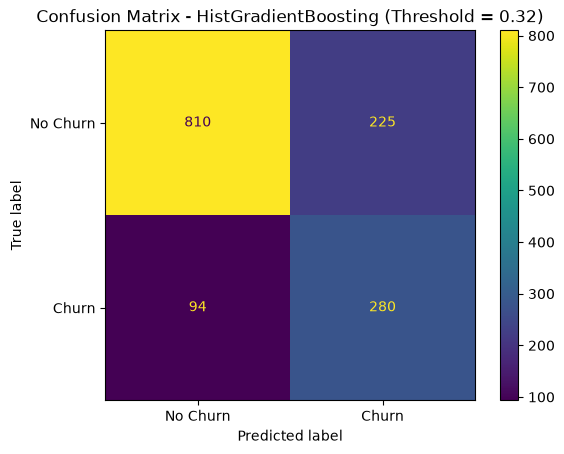

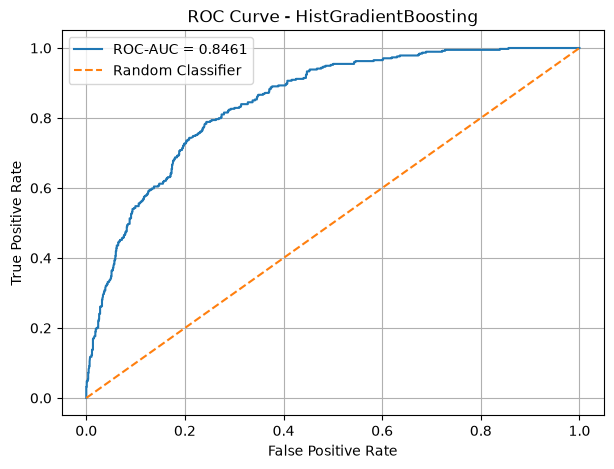

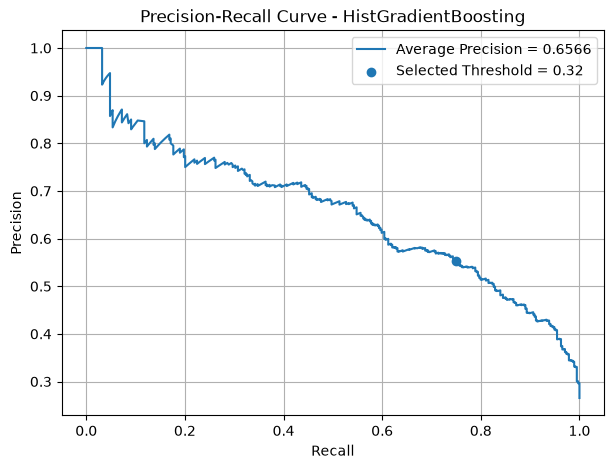

In [82]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt

# -----------------------------------
# Final selected model
# -----------------------------------

final_model = models['HistGradientBoosting']
final_threshold = final_thresholds['HistGradientBoosting']

# Fit on complete training data
final_model.fit(X_train, y_train)

# Test probabilities
y_prob_final = final_model.predict_proba(X_test)[:, 1]

# Apply CV-selected threshold
y_pred_final = (y_prob_final >= final_threshold).astype(int)


# ===================================
# 1. CONFUSION MATRIX
# ===================================

cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()
plt.title(
    f'Confusion Matrix - HistGradientBoosting '
    f'(Threshold = {final_threshold:.2f})'
)
plt.show()


# ===================================
# 2. ROC CURVE
# ===================================

fpr, tpr, _ = roc_curve(y_test, y_prob_final)

roc_auc = roc_auc_score(
    y_test,
    y_prob_final
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {roc_auc:.4f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - HistGradientBoosting')
plt.legend()
plt.grid()
plt.show()


# ===================================
# 3. PRECISION-RECALL CURVE
# ===================================

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob_final
)

average_precision = average_precision_score(
    y_test,
    y_prob_final
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label=f'Average Precision = {average_precision:.4f}'
)

plt.scatter(
    recall[np.argmin(abs(thresholds_pr - final_threshold))]
    if len(thresholds_pr) > 0 else recall[-1],
    precision[np.argmin(abs(thresholds_pr - final_threshold))]
    if len(thresholds_pr) > 0 else precision[-1],
    label=f'Selected Threshold = {final_threshold:.2f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - HistGradientBoosting')
plt.legend()
plt.grid()
plt.show()